# DDSP Timbre Transfer (Local)

This notebook loads a local DDSP checkpoint and resynthesizes audio using extracted f0 and loudness features.

Requirements: `ddsp`, `librosa`, `soundfile`, `tensorflow`, and `gin`.

In [1]:
import glob
import os
import time
import sys
from pathlib import Path

import gin
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import tensorflow.compat.v2 as tf

import ddsp
import ddsp.training

# Add src to path for local imports
PROJECT_ROOT = Path("../../../").resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from model_loading import find_model_dir, find_gin_file, find_latest_checkpoint, load_pretrained_model
from feature_utils import (
    auto_adjust_features,
    compute_features,
    load_dataset_stats,
    shift_f0,
    shift_loudness,
    trim_features,
)
from timbre_transfer import TimbreTransfer
from utils import DEFAULT_SAMPLE_RATE
from visualize import plot_spectrograms, plot_features

2026-04-19 11:18:18.306291: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-19 11:18:18.384729: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 11:18:22.119970: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib
2026-04-19 11:18:22.120143: W tensorflow/compi

In [2]:
# Parameters
input_audio_path = PROJECT_ROOT / "data/raw/voice/acapella/adele-set-fire-to-the-rain-studio-acapella_vocals.wav"
output_audio_dir = PROJECT_ROOT / "data/processed/voice/acapella_transfered"
sample_rate = DEFAULT_SAMPLE_RATE

# Pretrained model: Violin, Flute, Flute2, Trumpet, Tenor_Saxophone
# model_name = "Violin"
local_model_dir = PROJECT_ROOT / "artifacts/solo_instrument"
# Optional: extract a segment (set to None to use entire file)
start_sec = 103  # e.g. 2 * 60 + 7 for 2:07
end_sec   = 118  # e.g. 2 * 60 + 25 for 2:25

pitch_shift = 0.0        # octaves
loudness_shift = 0.0     # dB
auto_adjust = False       # match pitch register + loudness to training data

threshold = 1.0          # note detection sensitivity
quiet = 20           # suppress silent regions (dB)
autotune = 0.0           # snap to nearest scale note (0 = off, 1 = full)

# Silence frames whose CREPE pitch confidence is below this threshold.
# Set to 0.0 to disable. Typical useful range: 0.3 – 0.7.
pitch_confidence_threshold = 0.90

In [3]:
# Load audio
if not os.path.isfile(input_audio_path):
    raise FileNotFoundError(f"Audio file not found: {input_audio_path}")

full_audio, _ = librosa.load(str(input_audio_path), sr=sample_rate, mono=True)

# Optionally extract a segment
if start_sec is not None and end_sec is not None:
    start_sample = int(start_sec * sample_rate)
    end_sample   = int(end_sec * sample_rate)
    segment = full_audio[start_sample:end_sample]
    print(f"Loaded: {input_audio_path}")
    print(f"  Full length: {len(full_audio)/sample_rate:.1f}s")
    print(f"  Extracted segment: {start_sec}s – {end_sec}s ({len(segment)/sample_rate:.2f}s)")
else:
    segment = full_audio
    print(f"Loaded: {input_audio_path} ({len(segment)/sample_rate:.2f}s)")
def _format_timestamp(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    return f"{hours:02d}-{minutes:02d}-{secs:02d}" if hours else f"{minutes:02d}-{secs:02d}"

input_path = Path(input_audio_path)
if start_sec is not None and end_sec is not None:
    time_tag = f"_{_format_timestamp(start_sec)}_to_{_format_timestamp(end_sec)}"
else:
    time_tag = "_full"

segmented_audio_path = input_path.with_name(f"{input_path.stem}{time_tag}{input_path.suffix}")
# sf.write(str(segmented_audio_path), segment, sample_rate)
print(f"Saved segmented audio to: {segmented_audio_path}")
from IPython.display import Audio, display
display(Audio(segment, rate=sample_rate))

Loaded: /m/home/home3/37/thieun1/unix/Project/final_project/data/raw/voice/acapella/adele-set-fire-to-the-rain-studio-acapella_vocals.wav
  Full length: 235.0s
  Extracted segment: 103s – 118s (15.00s)
Saved segmented audio to: /m/home/home3/37/thieun1/unix/Project/final_project/data/raw/voice/acapella/adele-set-fire-to-the-rain-studio-acapella_vocals_01-43_to_01-58.wav


In [4]:
# Compute features
audio = segment[np.newaxis, :]
audio_features = compute_features(audio)

# Build output path from input filename
input_stem = Path(input_audio_path).stem
output_audio = os.path.join(output_audio_dir, f"{input_stem}_TRANSFERED.wav")

audio_items = [
    {
        "input_path": str(input_audio_path),
        "output_path": output_audio,
        "audio": audio,
        "features": audio_features,
    }
]
print(f"Computed features for segment ({segment.shape[0]/sample_rate:.2f}s)")

2026-04-19 11:18:49.420852: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-19 11:18:49.698558: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-19 11:18:49.701420: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-19 11:18:49.705097: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

Computed features for segment (15.00s)


In [5]:

model_dir = find_model_dir(local_model_dir)
gin_file = find_gin_file(model_dir)
print(f"Found model directory: {model_dir}")
print(f"Using gin config: {gin_file}")

# Load dataset stats for auto-adjust
dataset_stats = load_dataset_stats(model_dir)
print(f"Dataset stats: {'loaded' if dataset_stats else 'not found (auto-adjust will be skipped)'}")

# Detect whether the checkpoint's gin config includes a Reverb processor.
# Some checkpoints are trained without reverb — in that case we skip the
# extra "no-reverb" variant entirely and just use the single model.
with open(gin_file) as _f:
    _gin_text = _f.read()
has_reverb = "Reverb" in _gin_text
print(f"Model has reverb: {has_reverb}")

# Gin override to remove the Reverb processor from the DAG (only used when
# the base model actually has reverb).
NO_REVERB_DAG = [
    "ProcessorGroup.dag = ["
    "  (@synths.Harmonic(), ['amps', 'harmonic_distribution', 'f0_hz']),"
    "  (@synths.FilteredNoise(), ['noise_magnitudes']),"
    "  (@processors.Add(), ['filtered_noise/signal', 'harmonic/signal']),"
    "]"
]

# --- Main model (with reverb if available, otherwise the no-reverb model) ---
tt = TimbreTransfer(model_dir, gin_file)
tt.load()
time_steps = tt.time_steps
n_samples = tt.n_samples
hop_size = n_samples // time_steps
print(f"Alignment: {time_steps} frames x {hop_size} hop = {n_samples} samples")

# --- Optional no-reverb variant (only when base model has reverb) ---
if has_reverb:
    tt_no_reverb = TimbreTransfer(model_dir, gin_file, gin_overrides=NO_REVERB_DAG)
    tt_no_reverb.load()
    print("Loaded no-reverb model variant")
else:
    tt_no_reverb = None
    print("No-reverb variant skipped (base model already has no reverb)")


def _apply_pitch_confidence_filter(feats, thresh):
    """Silence frames whose pitch confidence is below *thresh*.

    Sets loudness to the minimum of the current loudness array for
    low-confidence frames, which makes the synth produce silence there
    without altering the surrounding f0 contour.
    """
    if thresh <= 0.0:
        return feats
    conf = np.asarray(feats["f0_confidence"])
    mask = conf < thresh
    if not mask.any():
        return feats
    ld = np.asarray(feats["loudness_db"], dtype=np.float32).copy()
    ld[mask] = float(ld.min())
    feats["loudness_db"] = ld
    print(f"    pitch-conf filter: silenced {mask.sum()}/{len(conf)} frames (<{thresh})")
    return feats


demo_audio = None
demo_audio_gen = None
demo_audio_gen_no_reverb = None

for idx, item in enumerate(audio_items):
    audio = item["audio"]
    audio_features = {k: v.copy() if hasattr(v, 'copy') else v
                      for k, v in item["features"].items()}

    # 1. Auto-adjust: match pitch register + loudness to training data
    if auto_adjust and dataset_stats is not None:
        audio_features = auto_adjust_features(
            audio_features,
            dataset_stats,
            threshold=threshold,
            quiet=quiet,
            autotune_amount=autotune,
        )
        print(f"  [{idx}] Applied auto-adjust (threshold={threshold}, quiet={quiet}dB, autotune={autotune})")
    else:
        print(f"  [{idx}] Auto-adjust skipped")

    # 2. Manual shifts
    audio_features = shift_loudness(audio_features, loudness_shift)
    audio_features = shift_f0(audio_features, pitch_shift)

    # 3. Pitch-confidence filter (silences unreliable frames)
    audio_features = _apply_pitch_confidence_filter(
        audio_features, pitch_confidence_threshold
    )

    # 4. Resynthesize — main model
    audio_gen = tt.synthesize(audio_features)

    # 5. Resynthesize — no-reverb variant (if available)
    if tt_no_reverb is not None:
        audio_gen_no_reverb = tt_no_reverb.synthesize(audio_features)
    else:
        audio_gen_no_reverb = None

    os.makedirs(os.path.dirname(item["output_path"]), exist_ok=True)
    sf.write(item["output_path"], audio_gen, sample_rate)
    print(f"  [{idx}] Wrote {item['output_path']}")

    if audio_gen_no_reverb is not None:
        no_reverb_path = item["output_path"].replace("_TRANSFERED", "_TRANSFERED_no_reverb")
        sf.write(no_reverb_path, audio_gen_no_reverb, sample_rate)
        print(f"  [{idx}] Wrote {no_reverb_path}")

    if idx == 0:
        demo_audio = audio
        demo_audio_gen = audio_gen
        demo_audio_gen_no_reverb = audio_gen_no_reverb

# Keep the first sample for display
audio = demo_audio
audio_gen = demo_audio_gen
audio_gen_no_reverb = demo_audio_gen_no_reverb

Found model directory: /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/solo_instrument
Using gin config: /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/solo_instrument/operative_config-57000.gin
Dataset stats: not found (auto-adjust will be skipped)
Model has reverb: True


/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)
/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/crepe/core.py:209: RuntimeWarning: invalid value encountered in divide
  frames /= np.std(frames, axis=1)[:, np.newaxis]
/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Alignment: 1000 frames x 64 hop = 64000 samples


/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/crepe/core.py:209: RuntimeWarning: invalid value encountered in divide
  frames /= np.std(frames, axis=1)[:, np.newaxis]
/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Loaded no-reverb model variant
  [0] Auto-adjust skipped
    pitch-conf filter: silenced 1813/3751 frames (<0.9)
  [0] Wrote /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/voice/acapella_transfered/adele-set-fire-to-the-rain-studio-acapella_vocals_TRANSFERED.wav
  [0] Wrote /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/voice/acapella_transfered/adele-set-fire-to-the-rain-studio-acapella_vocals_TRANSFERED_no_reverb.wav


In [6]:
# Listen back — compare original, main model, and (if available) no-reverb
from IPython.display import Audio, display

print("Original audio:")
display(Audio(audio[0], rate=sample_rate))

label_main = "Timbre transfer — with reverb:" if has_reverb else "Timbre transfer:"
print(label_main)
display(Audio(audio_gen, rate=sample_rate))

if audio_gen_no_reverb is not None:
    print("Timbre transfer — without reverb:")
    display(Audio(audio_gen_no_reverb, rate=sample_rate))

Original audio:


Timbre transfer — with reverb:


Timbre transfer — without reverb:


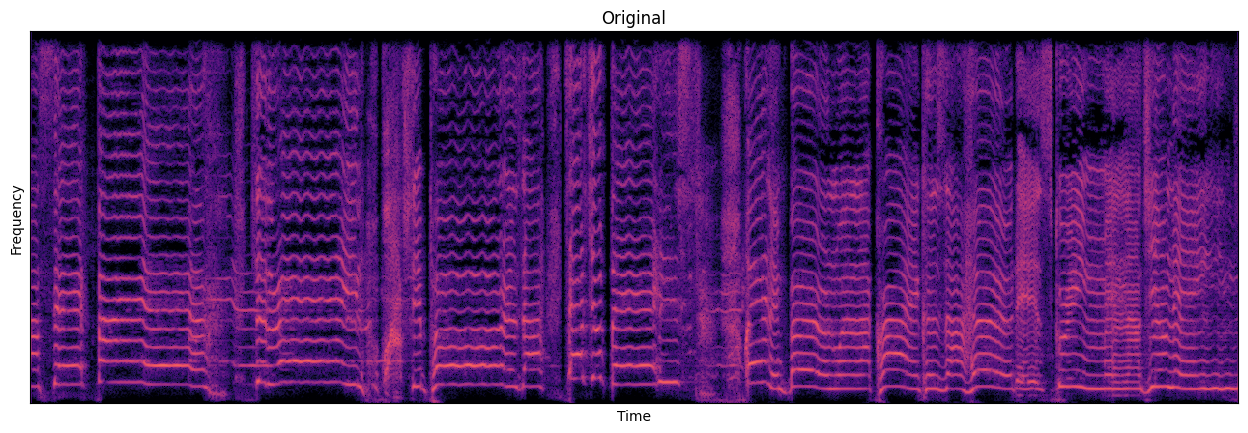

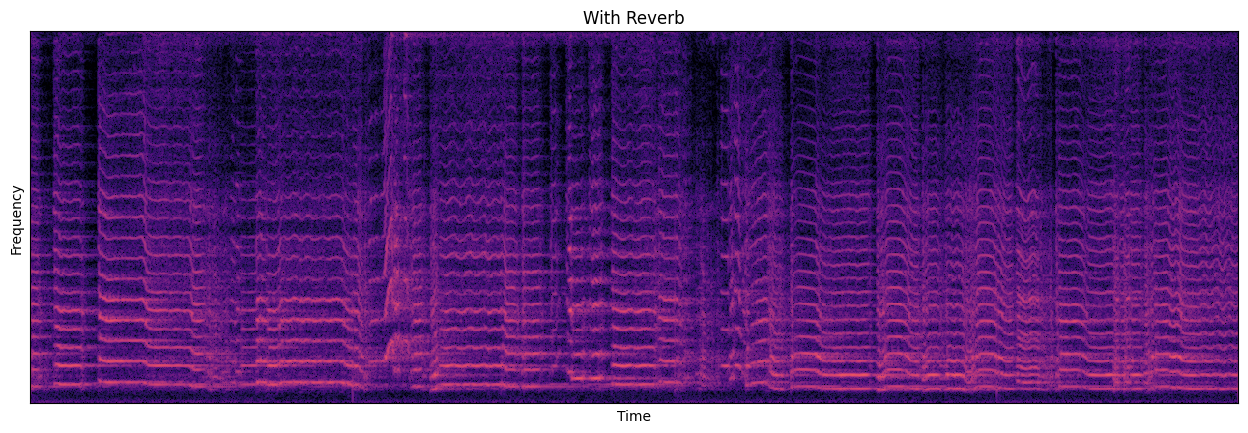

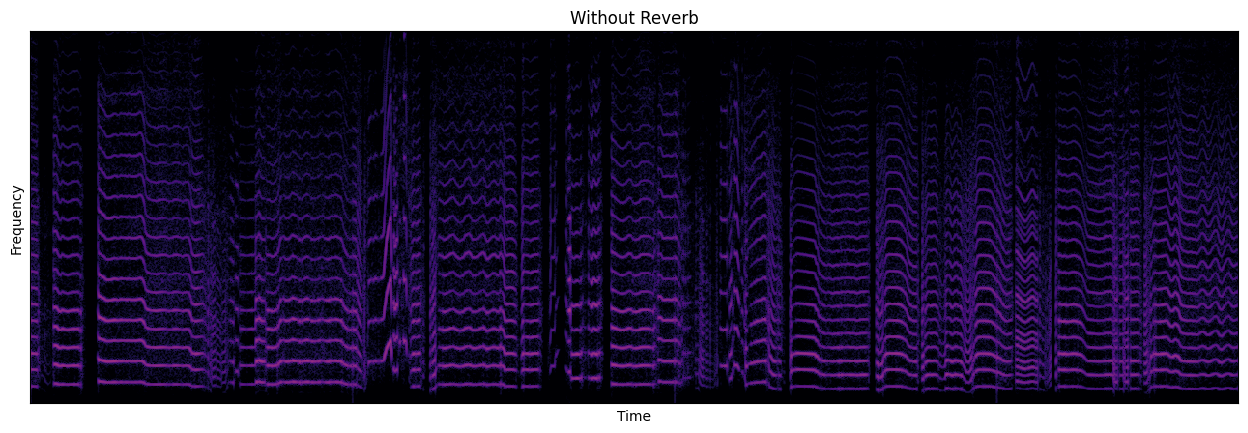

In [7]:
# Spectrograms — original vs main (+ no-reverb if available)
_signals = [audio[0], audio_gen]
_titles = ["Original", "With Reverb" if has_reverb else "DDSP (no reverb)"]
if audio_gen_no_reverb is not None:
    _signals.append(audio_gen_no_reverb)
    _titles.append("Without Reverb")

plot_spectrograms(_signals, sample_rate, titles=_titles)

Original audio features:


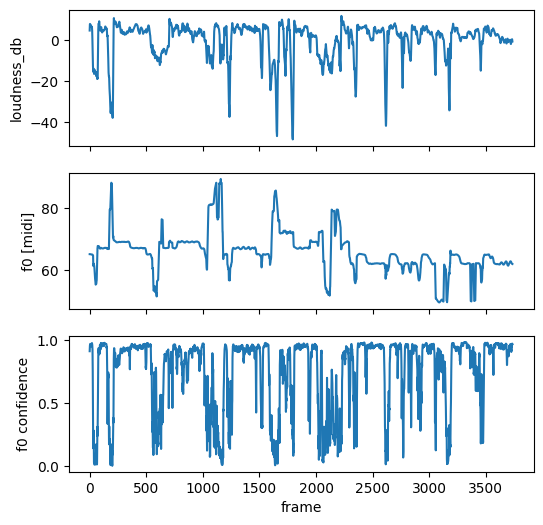

Generated audio features:


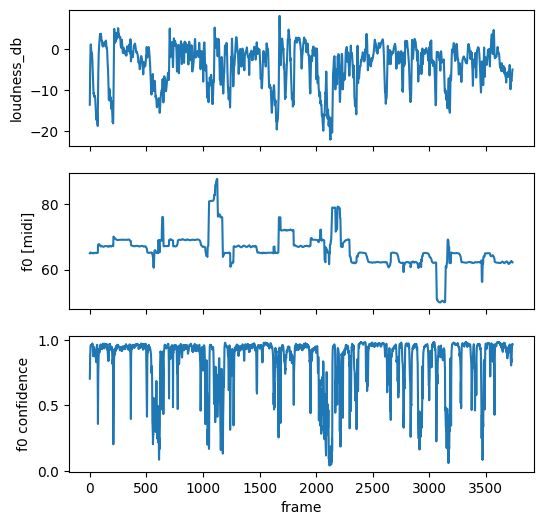

In [8]:
# Audio features (original input)
print("Original audio features:")
plot_features(audio_items[0]["features"])

# Recompute features on the generated audio for comparison
audio_gen_features = compute_features(audio_gen[np.newaxis, :])
print("Generated audio features:")
plot_features(audio_gen_features)